READ ME:

Original Question: How do the other features of each day for the AAPL stock affect and predict the next day of closing stock?

Description of Datasets used:
AAPL_Stock_Price_Dataset = Dataset showing AAPL stock prices from 1980 to 2025. This dataset also accounts for stock splits.
HistoricalQuotes = Dataset showing AAPL stock prices from 2010 to 2020. This dataset does NOT account for stock splits.

Joins performed: Merged a dataset with stock splits accounted for and the dataset where stock splits are NOT accounted for to create a dataset spanning 2010 to 2020, that does account for stock splits, and also lists the actual price that did not account for stock splits.

Final Dataset Shape: 2518 Rows, 15 Columns

In [24]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

In [25]:
df1 = pd.read_csv('AAPL_Stock_Price_Dataset_NEW.csv')
df2 = pd.read_csv('HistoricalQuotes_NEW.csv')

df1['Date'] = pd.to_datetime(df1['Date'])
df2['Date'] = pd.to_datetime(df2['Date'])

df2.columns = df2.columns.str.strip()
df2 = df2.rename(columns={'Close/Last':'Close'})

df1

,Date,Open,High,Low,Close,Volume,Daily_Return,Price_Range,Price_Change
0,1980-12-15,0.093684,0.093684,0.093256,0.093256,175884800,NaN,0.000428,-0.000428
1,1980-12-16,0.086839,0.086839,0.086412,0.086412,105728000,-7.339797,0.000428,-0.000428
2,1980-12-17,0.088550,0.088978,0.088550,0.088550,86441600,2.475132,0.000428,0.000000
3,1980-12-18,0.091118,0.091545,0.091118,0.091118,73449600,2.899260,0.000428,0.000000
4,1980-12-19,0.096678,0.097106,0.096678,0.096678,48630400,6.102835,0.000428,0.000000
...,...,...,...,...,...,...,...,...,...
11349,2025-12-24,272.339996,275.429993,272.200012,273.809998,17910600,0.532388,3.229980,1.470001
11350,2025-12-26,274.160004,275.369995,272.859985,273.399994,21521800,-0.149740,2.510010,-0.760010
11351,2025-12-29,272.690002,274.359985,272.350006,273.760010,23715200,0.131681,2.009979,1.070007
11352,2025-12-30,272.809998,274.079987,272.279999,273.079987,22139600,-0.248401,1.799988,0.269989


In [26]:
merged = df2.merge(df1, how="inner", on="Date", suffixes=('_Splits','_NoSplits'))

merged

,Date,Close_Splits,Volume_Splits,Open_Splits,High_Splits,Low_Splits,Open_NoSplits,High_NoSplits,Low_NoSplits,Close_NoSplits,Volume_NoSplits,Daily_Return,Price_Range,Price_Change
0,2020-02-28,$273.36,106721200,$257.26,$278.41,$256.37,62.218845,67.334013,62.003593,66.112656,426510000,-0.058474,5.330420,3.893811
1,2020-02-27,$273.52,80151380,$281.1,$286,$272.96,67.984578,69.169651,66.015900,66.151337,320605600,-6.536836,3.153751,-1.833242
2,2020-02-26,$292.65,49678430,$286.53,$297.88,$286.5,69.297844,72.042865,69.290589,70.777977,198054800,1.586375,2.752277,1.480133
3,2020-02-25,$288.08,57668360,$300.95,$302.53,$286.13,72.785347,73.167470,69.201100,69.672707,230673600,-3.387245,3.966371,-3.112641
4,2020-02-24,$298.18,55548830,$297.26,$304.18,$289.23,71.892933,73.566545,69.950862,72.115433,222195200,-4.750027,3.615683,0.222500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2513,2010-03-05,$31.2786,224647427,$30.7057,$31.3857,$30.6614,6.446276,6.589033,6.436978,6.566540,899620400,3.910617,0.152055,0.120264
2514,2010-03-04,$30.1014,89591907,$29.8971,$30.1314,$29.8043,6.276525,6.325710,6.257030,6.319412,366041200,0.659214,0.068680,0.042887
2515,2010-03-03,$29.9043,92846488,$29.8486,$29.9814,$29.7057,6.266330,6.294222,6.236339,6.278026,372052800,0.229838,0.057882,0.011696
2516,2010-03-02,$29.8357,141486282,$29.99,$30.1186,$29.6771,6.296020,6.323012,6.230339,6.263630,566546400,-0.066986,0.092672,-0.032390


The column we joined on was the "Date" column.

The type of join we used is an inner join. We used this join so that we kept all of the keys from both datasets, as we needed both.

Number of rows before join: 2518

Number of rows after join: 2518

Why row count stayed the same: The row count stayed the same because we are only adding new keys that account for stock splits into our dataset, not new dates.

In [27]:
# Adding catagorical variable

merged['Profit'] = merged['Price_Change'] > 0

merged

,Date,Close_Splits,Volume_Splits,Open_Splits,High_Splits,Low_Splits,Open_NoSplits,High_NoSplits,Low_NoSplits,Close_NoSplits,Volume_NoSplits,Daily_Return,Price_Range,Price_Change,Profit
0,2020-02-28,$273.36,106721200,$257.26,$278.41,$256.37,62.218845,67.334013,62.003593,66.112656,426510000,-0.058474,5.330420,3.893811,True
1,2020-02-27,$273.52,80151380,$281.1,$286,$272.96,67.984578,69.169651,66.015900,66.151337,320605600,-6.536836,3.153751,-1.833242,False
2,2020-02-26,$292.65,49678430,$286.53,$297.88,$286.5,69.297844,72.042865,69.290589,70.777977,198054800,1.586375,2.752277,1.480133,True
3,2020-02-25,$288.08,57668360,$300.95,$302.53,$286.13,72.785347,73.167470,69.201100,69.672707,230673600,-3.387245,3.966371,-3.112641,False
4,2020-02-24,$298.18,55548830,$297.26,$304.18,$289.23,71.892933,73.566545,69.950862,72.115433,222195200,-4.750027,3.615683,0.222500,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2513,2010-03-05,$31.2786,224647427,$30.7057,$31.3857,$30.6614,6.446276,6.589033,6.436978,6.566540,899620400,3.910617,0.152055,0.120264,True
2514,2010-03-04,$30.1014,89591907,$29.8971,$30.1314,$29.8043,6.276525,6.325710,6.257030,6.319412,366041200,0.659214,0.068680,0.042887,True
2515,2010-03-03,$29.9043,92846488,$29.8486,$29.9814,$29.7057,6.266330,6.294222,6.236339,6.278026,372052800,0.229838,0.057882,0.011696,True
2516,2010-03-02,$29.8357,141486282,$29.99,$30.1186,$29.6771,6.296020,6.323012,6.230339,6.263630,566546400,-0.066986,0.092672,-0.032390,False


In [28]:
merged.shape

(2518, 15)

In [29]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2518 entries, 0 to 2517
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             2518 non-null   datetime64[ns]
 1   Close_Splits     2518 non-null   object        
 2   Volume_Splits    2518 non-null   int64         
 3   Open_Splits      2518 non-null   object        
 4   High_Splits      2518 non-null   object        
 5   Low_Splits       2518 non-null   object        
 6   Open_NoSplits    2518 non-null   float64       
 7   High_NoSplits    2518 non-null   float64       
 8   Low_NoSplits     2518 non-null   float64       
 9   Close_NoSplits   2518 non-null   float64       
 10  Volume_NoSplits  2518 non-null   int64         
 11  Daily_Return     2518 non-null   float64       
 12  Price_Range      2518 non-null   float64       
 13  Price_Change     2518 non-null   float64       
 14  Profit           2518 non-null   bool   

In [30]:
merged.describe

<bound method NDFrame.describe of            Date Close_Splits  Volume_Splits Open_Splits High_Splits  \
0    2020-02-28      $273.36      106721200     $257.26     $278.41   
1    2020-02-27      $273.52       80151380      $281.1        $286   
2    2020-02-26      $292.65       49678430     $286.53     $297.88   
3    2020-02-25      $288.08       57668360     $300.95     $302.53   
4    2020-02-24      $298.18       55548830     $297.26     $304.18   
...         ...          ...            ...         ...         ...   
2513 2010-03-05     $31.2786      224647427    $30.7057    $31.3857   
2514 2010-03-04     $30.1014       89591907    $29.8971    $30.1314   
2515 2010-03-03     $29.9043       92846488    $29.8486    $29.9814   
2516 2010-03-02     $29.8357      141486282      $29.99    $30.1186   
2517 2010-03-01     $29.8557      137312041    $29.3928    $29.9286   

     Low_Splits  Open_NoSplits  High_NoSplits  Low_NoSplits  Close_NoSplits  \
0       $256.37      62.218845    

Part 2 Exploratory Question
You must answer at least four specific EDA questions using visualization.

Each question must:
Be clearly stated
Use Pandas operations
Include one iplot() visualization

Include a written interpretation of 3 to 5 full sentences

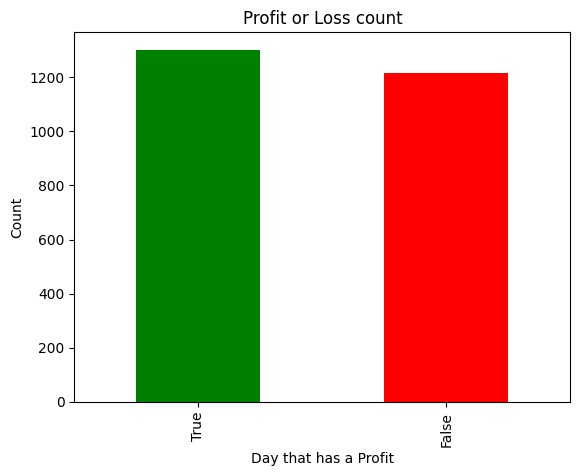

In [ ]:
#1. Category Counts (Bar Chart)
#Question: Is there more days where there is a profit or a loss.
profitNoProfit_count = merged["Profit"].value_counts()
colors = ['red' if category == False else 'green' for category in profitNoProfit_count.index]
merged["Profit"].value_counts().plot(kind='bar', color= colors)
plt.title('Profit or Loss count')
plt.xlabel('Day that has a Profit')
plt.ylabel('Count')
plt.show()

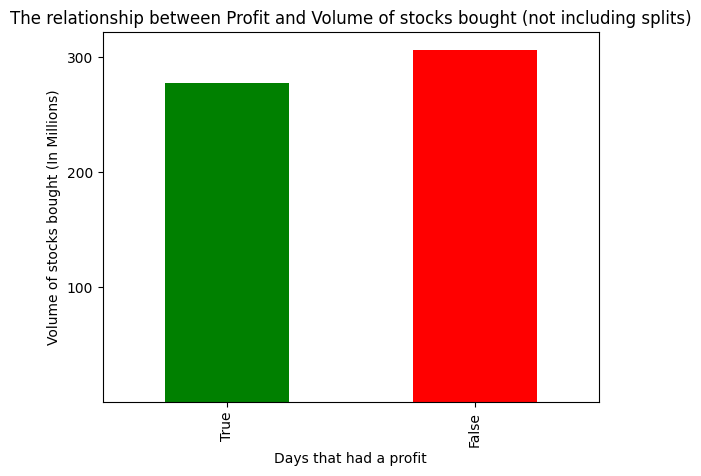

In [ ]:
#2. Grouped Aggregation (Bar Chart)
#What is the relationship between the days that make a profit and the number of shares bought during that day?
groupedData = merged.groupby("Profit")["Volume_NoSplits"].mean()
groupedData = groupedData.sort_index(ascending=False)
groupedData_count = groupedData.value_counts()
colors = ['red' if profit == False else 'green' for profit in groupedData.index]

groupedData.plot(kind="bar", color = colors)
plt.title("The relationship between Profit and Volume of stocks bought (not including splits)")
plt.yticks(ticks=[1e8, 2e8, 3e8], labels=['100', '200', '300'])
plt.ylabel("Volume of stocks bought (In Millions)")
plt.xlabel("Days that had a profit")
plt.show()

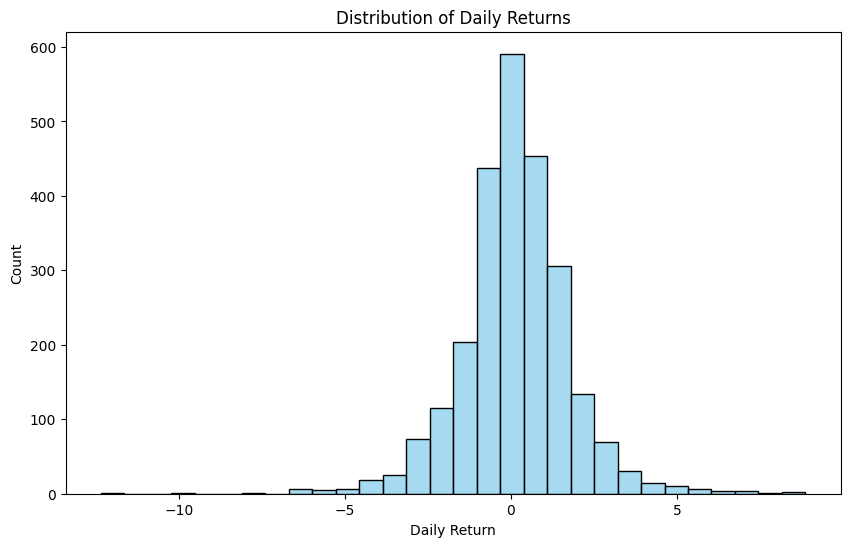

In [ ]:
#3. Distribution (Histogram)
#Is the distribution of daily returns skewed?
plt.figure(figsize=(10,6))

sb.histplot(merged['Daily_Return'], bins=30, color='skyblue', edgecolor='black')

plt.title('Distribution of Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Count')
plt.show()

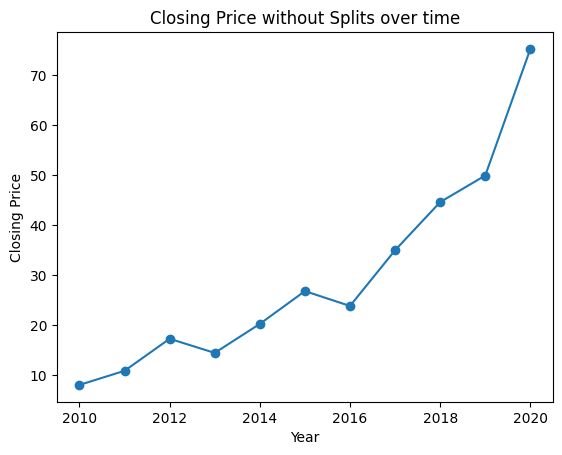

In [126]:
#4. Trend or Top-N Comparison
#How is the average closing price without splits differ among different years
merged.groupby(merged["Date"].dt.year)['Close_NoSplits'].mean().plot(kind="line",marker='o')

plt.title("Closing Price without Splits over time")
plt.xlabel("Year")
plt.ylabel("Closing Price")
plt.show()